In [2]:
import sys
import os
import math
import torch
import platform
import copy
# import glob
import time
from torchsummary import summary
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    # CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS,
    MODELS_DIR 
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.layers import QuantizedLayerMixin

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Aff_INT8", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [3]:
def check_system_capabilities():
    print(f"--- System Info ---")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Python Version: {sys.version.split()[0]}")
    # FIX: Nutzung von platform statt torch.version.os
    print(f"OS: {platform.system()} ({platform.release()})")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    
    print(f"\n--- 1. Compiler Backends (for torchao/torch.compile) ---")
    backends = torch.compiler.list_backends()
    print(f"Available Backends: {backends}")
    
    if 'inductor' in backends:
        print("-> 'inductor' is listed (Required for high-perf torchao).")
        # Check for Triton (the engine behind inductor)
        try:
            import triton
            print(f"-> SUCCESS: Triton is installed! Version: {triton.__version__}")
        except ImportError:
            print("-> WARNING: 'inductor' is listed, but 'triton' is NOT installed.")
            print("   If you are on Linux, try 'pip install triton'.")

    print(f"\n--- 2. Low-Level Quantization Engines ---")
    print(f"Supported Engines: {torch.backends.quantized.supported_engines}")
    print(f"Current Default Engine: {torch.backends.quantized.engine}")

    print(f"\n--- 3. MKLDNN / OneDNN Support (x86 Acceleration) ---")
    print(f"MKLDNN Available: {torch.backends.mkldnn.is_available()}")

In [4]:
def check_fx_quantization_type(model):
    """
    Spezielle Prüf-Funktion für FX Graph Mode Modelle.
    Sucht nach 'PackedParams', entpackt sie und prüft das Quantisierungs-Schema.
    """
    print("--- FX Quantisierungs-Check ---")
    found = False
    
    # Wir iterieren durch alle Attribute des Modells
    # FX speichert Gewichte oft als Attribute wie 'conv1_packed_weight_0'
    for name in dir(model):
        attr = getattr(model, name)
        
        # Prüfung: Ist es ein gepacktes Gewichtspaket?
        # Diese Objekte haben meist eine .unpack() Methode
        if hasattr(attr, 'unpack') and "packed_weight" in name:
            print(f"Untersuche Parameter-Paket: '{name}'")
            
            # Entpacken (gibt meist Weight, Bias zurück)
            try:
                weight, bias = attr.unpack()
                
                # Jetzt haben wir den echten quantisierten Tensor
                scheme = weight.qscheme()
                print(f"  QScheme: {scheme}")
                
                # Check auf Zero Point (der mathematische Beweis)
                if scheme in [torch.per_channel_symmetric, torch.per_tensor_symmetric]:
                    # Bei Symmetric muss ZP überall 0 sein
                    zps = weight.q_zero_point()
                    # Wenn zps ein Tensor ist, prüfen wir alle Werte
                    if torch.all(zps == 0):
                        print("  -> BESTÄTIGT: Symmetrisch (Alle Zero-Points sind 0).")
                    else:
                        print("  -> WARNUNG: Schema ist symmetrisch, aber Zero-Points sind ungleich 0!")
                        
                elif scheme in [torch.per_channel_affine, torch.per_tensor_affine]:
                    print("  -> BESTÄTIGT: Affine (Asymmetrisch).")
                
                found = True
                break # Ein Treffer reicht uns
            except Exception as e:
                print(f"  Konnte Paket nicht entpacken: {e}")

    if not found:
        print("Keine gepackten Gewichte gefunden. (Vielleicht ist das Modell noch Float?)")

In [5]:
def _fix_quantization_dtypes(module, method='affine', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    """
    Universal-Loader für Baseline UND Quantisierte Modelle.
    """
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    
    if quant_config:
        print(f"Repariere Quantisierung ({quant_config})...")
        method = quant_config.get('method', 'affine')
        bits = quant_config.get('bits', 8)

        for name, module in model.named_modules():
            # Wir prüfen duck-typing oder Klasse
            if hasattr(module, "quant_mode") or isinstance(module, QuantizedLayerMixin):
             _fix_quantization_dtypes(module, method, bits)
    else:
        print(" Baseline Modus (Float32).")
        if hasattr(model, 'convert_to_baseline'):
            model.convert_to_baseline()
            
    model.eval()
    return model

In [6]:
def get_all_predictions(model, data_loader, device='cpu'):
    """
    Kompilier-sichere Version von get_all_predictions.
    Verhindert model.to(device) Aufrufe für kompilierte Modelle.
    """
    # 1. Prüfen, ob Modell kompiliert ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn NICHT kompiliert
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    all_preds = []
    all_targets = []
    sample_images = [] # Zum Speichern für Visualisierung
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            # Daten müssen wir IMMER verschieben
            data = data.to(device)
            
            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(pred)
            all_targets.extend(target.numpy())
            
            # Ein paar Beispielbilder speichern (vom ersten Batch)
            if i == 0:
                sample_images = data.cpu()

    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [7]:
def measure_inference_time(model, data_loader, device='cpu'):
    # FIX: Prüfen, ob es ein kompiliertes Modell ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn es NICHT kompiliert ist
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    # Warm-up (kurz)
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= 5: break
            data = data.to(device)
            model(data)
            
    # Echte Messung
    start_time = time.time()
    count = 0
    
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            # Wir messen hier z.B. 100 Batches, damit es nicht ewig dauert
            if i >= 100: break
            
            data = data.to(device)
            model(data)
            count += data.size(0)
            
    end_time = time.time()
    
    total_time = end_time - start_time
    fps = count / total_time
    latency_ms = (total_time / count) * 1000
    
    return fps, latency_ms

In [8]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        name_q = class_names[p_quant] if class_names else str(p_quant)
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
train_loader, test_loader, num_classes = get_data_loaders()
dummy_input = next(iter(train_loader))[0].to('cpu')
# Versuche Klassennamen zu finden

class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])

print("Evaluiere Accuracy...")

# Baseline
summary(baseline_model, input_size=(3, 64, 64))
fps_base, lat_base = measure_inference_time(baseline_model, test_loader, device='cpu')
print(f"Baseline:  {fps_base:.2f} Bilder/sek | Latenz: {lat_base:.2f} ms")
res_base = get_all_predictions(baseline_model, test_loader, device='cpu')
print_metrics(res_base, "Baseline Model")



 Baseline Modus (Float32).
Evaluiere Accuracy...
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   QuantizedConv2d-1           [-1, 32, 64, 64]             896
   QuantizedConv2d-2           [-1, 64, 64, 64]          18,496
   QuantizedConv2d-3          [-1, 128, 64, 64]          73,856
   QuantizedConv2d-4          [-1, 256, 64, 64]         295,168
 AdaptiveAvgPool2d-5            [-1, 256, 2, 2]               0
           Dropout-6                 [-1, 1024]               0
   QuantizedLinear-7                 [-1, 1024]       1,049,600
   QuantizedLinear-8                  [-1, 150]         153,750
Total params: 1,591,766
Trainable params: 1,591,766
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 15.02
Params size (MB): 6.07
Estimated Total Size (MB): 21.14
----------------------------------------------------

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [10]:
#Int8 Weight and Activations of Linear Layers

print("\n=== Experiment 2: TorchAO Int8 Weight and Activations ===")

model_for_ao = copy.deepcopy(baseline_model)
ao_int8 = Quantization.apply_torchao_quantization(model_for_ao, method="dynamic")

print("Wärme auf (Weight und Activations Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_int8(dummy_input)
print("Fertig.")

fps_int8, lat_int8 = measure_inference_time(ao_int8, test_loader, device='cpu')
print(f"Int8:  {fps_int8:.2f} Bilder/sek | Latenz: {lat_int8:.2f} ms")
res_int8 = get_all_predictions(ao_int8, test_loader, device='cpu')
print_metrics(res_int8, "TorchAO Int8")

speedup8 = fps_int8 / fps_base
print(f"\n-> Beschleunigung: {speedup8:.2f}x schneller als Base")


=== Experiment 2: TorchAO Int8 Weight and Activations ===
--- TorchAO: Wende 'dynamic' Quantisierung an ---
Kompiliere mit torch.compile (Backend='inductor')...


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/utils.py:390: UserWarning: `int8_dynamic_activation_int8_weight` is deprecated and will be removed in a future release. Please use `Int8DynamicActivationInt8WeightConfig` instead. Example usage:
    quantize_(model, Int8DynamicActivationInt8WeightConfig(...))
  warnings.warn(


Wärme auf (Weight und Activations Kompilierung)...
Fertig.
Int8:  198.89 Bilder/sek | Latenz: 5.03 ms

--- Performance: TorchAO Int8 ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [11]:
# Int8 Weight Only of linear layers

print("\n=== Experiment 2: TorchAO Int8 Weight Only ===")

model_for_weight_only = copy.deepcopy(baseline_model)
ao_weight = Quantization.apply_torchao_quantization(model_for_weight_only, method="weight_only")

print("Wärme auf (IntWeight Only Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_weight(dummy_input)

fps_weight, lat_weight = measure_inference_time(ao_weight, test_loader, device='cpu')
print(f"Baseline:  {fps_weight:.2f} Bilder/sek | Latenz: {lat_weight:.2f} ms")
res_weight = get_all_predictions(ao_weight, test_loader, device='cpu')
print_metrics(res_weight, "TorchAO Weight only")

speedup_weight_only = fps_weight / fps_base
print(f"\n-> Beschleunigung: {speedup_weight_only:.2f}x schneller als Base")


=== Experiment 2: TorchAO Int8 Weight Only ===
--- TorchAO: Wende 'weight_only' Quantisierung an ---
Kompiliere mit torch.compile (Backend='inductor')...
Wärme auf (IntWeight Only Kompilierung)...


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/utils.py:390: UserWarning: `int8_weight_only` is deprecated and will be removed in a future release. Please use `Int8WeightOnlyConfig` instead. Example usage:
    quantize_(model, Int8WeightOnlyConfig(...))
  warnings.warn(
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/quantization/quant_api.py:1356: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Baseline:  205.55 Bilder/sek | Latenz: 4.87 ms

--- Performance: TorchAO Weight only ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     1.0000    0.9167    0.9565        12
    

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [12]:
# Int8 Autosearch Graph Optimization of Linear Layers

print("\n=== Experiment 3: TorchAO Int8 Auto ===")

model_for_auto = copy.deepcopy(baseline_model)
ao_auto = Quantization.apply_torchao_quantization(model_for_auto, method="auto", dummy_input=dummy_input)

print("Wärme auf (Auto Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_auto(dummy_input)

fps_auto, lat_auto = measure_inference_time(ao_auto, test_loader, device='cpu')
print(f"Baseline:  {fps_auto:.2f} Bilder/sek | Latenz: {lat_auto:.2f} ms")
res_auto = get_all_predictions(ao_auto, test_loader, device='cpu')
print_metrics(res_auto, "TorchAO ao_auto")

speedup_auto = fps_auto / fps_base
print(f"\n Beschleinigung: {speedup_auto:.2f}x schneller als Base")


=== Experiment 3: TorchAO Int8 Auto ===
--- TorchAO: Wende 'auto' Quantisierung an ---
Starte AutoQuant Analyse (Eager Mode)...
activation_shapes: torch.Size([64, 1024]), times_seen: 1
weight_shape: torch.Size([1024, 1024]), dtype: torch.float32, bias_shape: torch.Size([1024])


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()


>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQDefaultLinearWeight'>, to_beat: infms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8WeightOnlyQuantizedLinearWeight'>, to_beat: 0.001ms 


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()


>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'> matmul, to_beat: 0.001ms
best_cls=<class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'>

activation_shapes: torch.Size([64, 1024]), times_seen: 1
weight_shape: torch.Size([150, 1024]), dtype: torch.float32, bias_shape: torch.Size([150])
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQDefaultLinearWeight'>, to_beat: infms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8WeightOnlyQuantizedLinearWeight'>, to_beat: 0.001ms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'> matmul, to_beat: 0.001ms


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()


best_cls=<class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'>

AutoQuant hat die beste Strategie gewählt.
Kompiliere mit torch.compile (Backend='inductor')...
Wärme auf (Auto Kompilierung)...
Baseline:  210.42 Bilder/sek | Latenz: 4.75 ms

--- Performance: TorchAO ao_auto ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
     

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

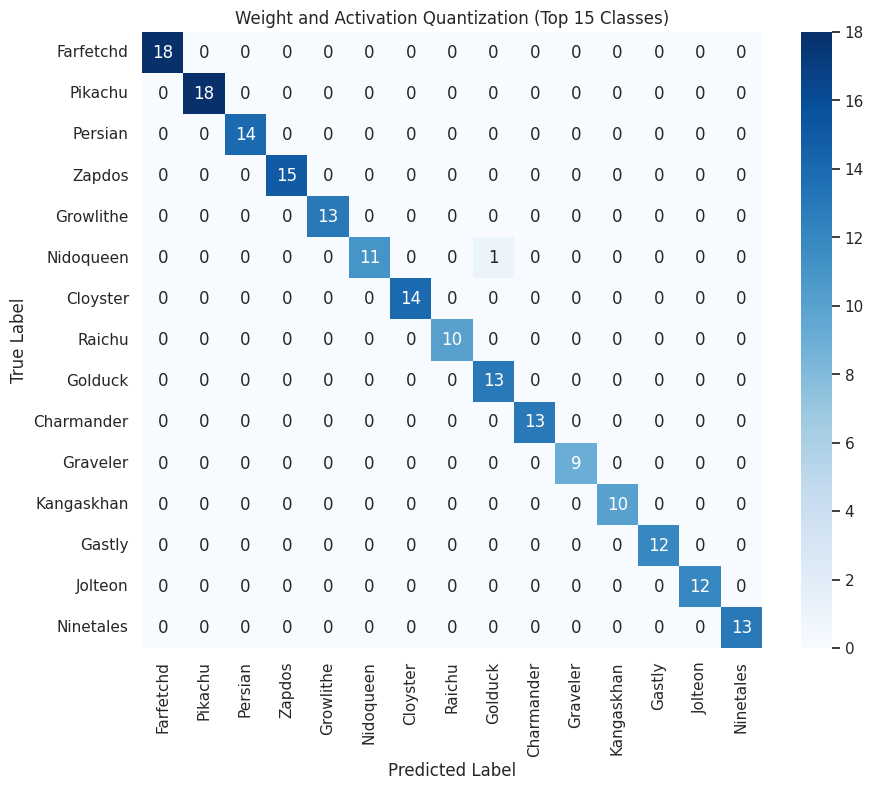

In [13]:

plot_confusion_matrix(res_int8['targets'], res_int8['preds'], class_names, title="Weight and Activation Quantization") 

In [23]:

from tabulate import tabulate
from torch.fx import passes

print("\n=== Experiment 4: Graph FX Quantization (Int8) ===")

model_for_fx = copy.deepcopy(baseline_model)
fx_model = Quantization.apply_fx_quantization(model_for_fx, train_loader, method="affine", num_batches=30)

with torch.no_grad():
    for _ in range(5): fx_model(dummy_input)
print("Fertig.")

g = passes.graph_drawer.FxGraphDrawer(fx_model, 'fx_quantized')
with open("fx_graph.svg", "wb") as f:
    print(g.get_dot_graph().to_string())

fps_fx, lat_fx = measure_inference_time(fx_model, test_loader, device='cpu')
print(f"Baseline:  {fps_fx:.2f} Bilder/sek | Latenz: {lat_fx:.2f} ms")
res_fx = get_all_predictions(fx_model, test_loader, device='cpu')
print_metrics(res_fx, "FX Affine")


speedup_fx = fps_fx / fps_base
print(f"\n Beschleinigung: {speedup_fx:.2f}x schneller als Base")


=== Experiment 4: Graph FX Quantization (Int8) ===
Starte FX Graph Mode Quantization (Methode: affine)...
Kalibriere mit 30 Batches...
Konvertiere Modell (Layer Fusion)...
FX Quantisierung abgeschlossen.
Fertig.
digraph fx_quantized {
rankdir=TB;
x [label="{name=%x|op_code=placeholder\n|target=x\n|num_users=1\n}", shape=record, fillcolor="AliceBlue", style="filled,rounded", fontcolor="#000000"];
conv1_input_scale_0 [label="{name=%conv1_input_scale_0|op_code=get_attr\n|target=conv1_input_scale_0\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
conv1_input_zero_point_0 [label="{name=%conv1_input_zero_point_0|op_code=get_attr\n|target=conv1_input_zero_point_0\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
quantize_per_tensor [label="{name=%quantize_per_tensor|op_code=call_function\n|target=torch.quantize_per_tensor\n|args=(torch.quint8,)|num_users=1\n}", shape=record, fillcolor=GhostWh

Repariere Quantisierung ({'method': 'affine', 'bits': 8})...

=== Experiment 5: Custome Affine Simulation ===
Int8:  126.82 Bilder/sek | Latenz: 7.89 ms

--- Performance: Custome Affine Int8 ---
Accuracy:   0.9113 (91.13%)
Error Rate: 0.0887 (8.87%)
----------------------------------------
              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474         9
           1     1.0000    0.9000    0.9474        10
           2     0.6667    0.8000    0.7273         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.5833    0.7368        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     0.8333    1.0000    0.9091        10
           9     0.3750    1.0000    0.5455         3
          10     1.0000    1.0000    1.0000         6
          11     1.0000    1.0000    1.0000         4
      

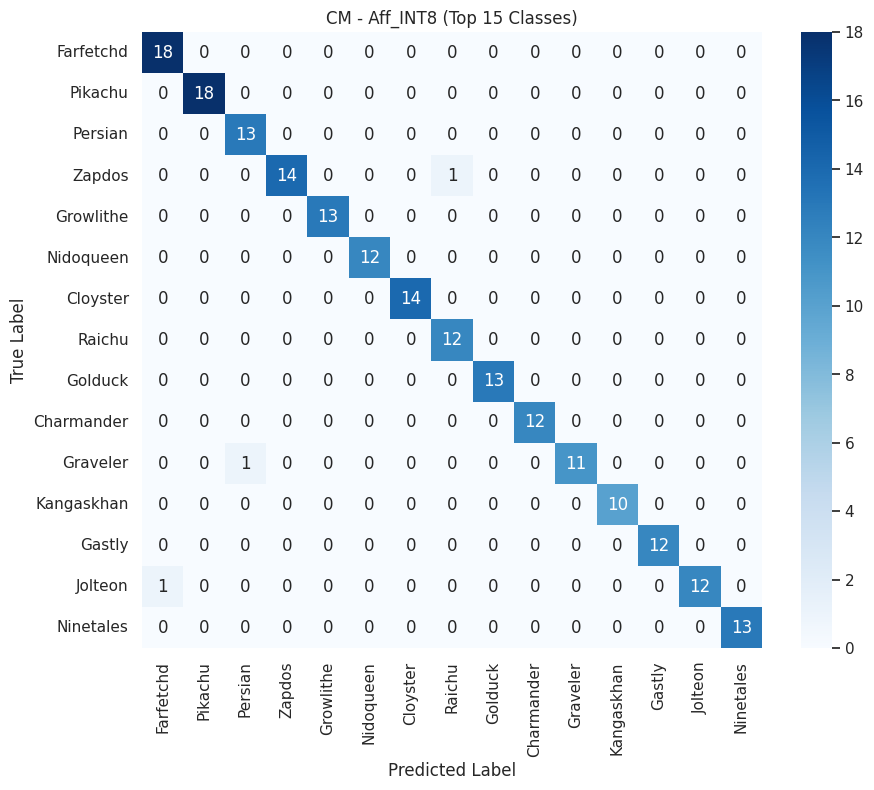

In [ ]:
# Config ableiten (Automatisch aus dem Namen)

q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Aff' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8

# Custome quantized affine int8 
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model_affine = load_model(
    CNN,
    num_classes,
    q_path,
    quant_config={'method': q_method, 'bits': q_bits}
).to('cpu')


print("\n=== Experiment 5: Custome Affine Simulation ===")
model_for_custome_affine = copy.deepcopy(quantized_model_affine)

fps_custome_affine, lat_custome_affine = measure_inference_time(model_for_custome_affine, test_loader, device='cpu')
print(f"Int8:  {fps_custome_affine:.2f} Bilder/sek | Latenz: {lat_custome_affine:.2f} ms")
res_custome_affine = get_all_predictions(model_for_custome_affine, test_loader, device='cpu')
print_metrics(res_custome_affine, "Custome Affine Int8")

speedup_custome = fps_custome_affine / fps_base
print(f"\n-> Beschleunigung: {speedup_custome:.2f}x schneller als Base")


plot_confusion_matrix(res_custome_affine['targets'], res_custome_affine['preds'], class_names, title=f"CM - {q_name}") 

In [ ]:
from tabulate import tabulate
from torch.fx import passes

print("\n=== Experiment 6: Graph FX Quantization (Int8) Symmetrisch ===")

model_for_fx_sym = copy.deepcopy(baseline_model)
model_for_fx_sym = model_for_fx_sym.to(memory_format=torch.channels_last)

fx_model_sym = Quantization.apply_fx_quantization(model_for_fx_sym, train_loader, method="symmetric", num_batches=30)

# fx_model_sym.graph.print_tabular()

# Generates a visual representation
g = passes.graph_drawer.FxGraphDrawer(fx_model_sym, 'fx_quantized')
with open("fx_graph.svg", "wb") as f:
    print(g.get_dot_graph().to_string())

with torch.no_grad():
    for _ in range(5): fx_model_sym(dummy_input)
print("Fertig.")

fps_fx_sym, lat_fx_sym = measure_inference_time(fx_model_sym, test_loader, device='cpu')
print(f"Baseline:  {fps_fx_sym:.2f} Bilder/sek | Latenz: {lat_fx_sym:.2f} ms")
res_fx_sym = get_all_predictions(fx_model_sym, test_loader, device='cpu')
print_metrics(res_fx_sym, "FX Affine")


speedup_fx_sym = fps_fx_sym / fps_base
print(f"\n Beschleinigung: {speedup_fx_sym:.2f}x schneller als Base")



=== Experiment 6: Graph FX Quantization (Int8) Symmetrisch ===
Starte FX Graph Mode Quantization (Methode: symmetric)...
Kalibriere mit 30 Batches...
Konvertiere Modell (Layer Fusion)...
FX Quantisierung abgeschlossen.
digraph fx_quantized {
rankdir=TB;
x [label="{name=%x|op_code=placeholder\n|target=x\n|num_users=1\n}", shape=record, fillcolor="AliceBlue", style="filled,rounded", fontcolor="#000000"];
conv1_weight [label="{name=%conv1_weight|op_code=get_attr\n|target=conv1.weight\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
conv1_bias [label="{name=%conv1_bias|op_code=get_attr\n|target=conv1.bias\n|num_users=1\n}", shape=record, fillcolor=LightGrey, style="filled,rounded", fontcolor="#000000"];
conv2d [label="{name=%conv2d|op_code=call_function\n|target=torch.conv2d\n|args=(\l(1, 1),\n(1, 1),\n(1, 1),\n1,\n)\l|num_users=1\n}", shape=record, fillcolor=Thistle3, style="filled,rounded", fontcolor="#000000"];
relu [label="{name=%relu

In [15]:
import torch.backends.mkldnn
print(f"MKLDNN verfügbar: {torch.backends.mkldnn.is_available()}")
print(f"Optimiert für Backend: {torch.backends.quantized.engine}")

MKLDNN verfügbar: True
Optimiert für Backend: x86


In [16]:
print([name for name, _ in baseline_model.named_modules()])

['', 'conv1', 'conv2', 'conv3', 'conv4', 'dropout', 'global_pool', 'fc1', 'fc2']


In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class ActivationCollector:
    def __init__(self, model, layer_types=(nn.Conv2d, nn.Linear)):
        self.hooks = []
        self.activations = {}
        self.model = model
        self.layer_types = layer_types

    def _get_hook(self, name):
        def hook(model, input, output):
            # Falls Output ein Tupel ist (passiert manchmal), nimm das erste Element
            if isinstance(output, tuple):
                out_tensor = output[0]
            else:
                out_tensor = output
            self.activations[name] = out_tensor.detach().cpu()
        return hook

    def register(self):
        # Versucht, rekursiv alle passenden Module zu finden
        for name, module in self.model.named_modules():
            # Prüfen ob es ein relevanter Layer ist (auch subclass check für Quantized Layer)
            if isinstance(module, self.layer_types) or \
               any(x in module.__class__.__name__ for x in ['QuantizedConv', 'QuantizedLinear']):
                
                self.hooks.append(module.register_forward_hook(self._get_hook(name)))

    def clear(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []
        self.activations = {}

def compare_layer_activations(model_base, model_quant, input_data, layer_key_substring=""):
    """
    Vergleicht Activations zwischen Base und Quant Modell.
    Handhabt automatisch unterschiedliche Devices (CPU/GPU) für die Modelle.
    """
    # Helper: Finde heraus, wo das Modell lebt
    def get_model_device(model):
        try:
            return next(model.parameters()).device
        except StopIteration:
            # Fallback für spezielle kompilierte Modelle ohne Parameter-Liste
            return torch.device("cpu")

    device_base = get_model_device(model_base)
    device_quant = get_model_device(model_quant)

    # 1. Collector einrichten
    collector_base = ActivationCollector(model_base)
    collector_quant = ActivationCollector(model_quant)
    
    collector_base.register()
    collector_quant.register()

    # 2. Forward Pass (Input jeweils auf das richtige Device schieben)
    with torch.no_grad():
        # Base Model Forward
        input_base = input_data.to(device_base)
        model_base(input_base)
        
        # Quant Model Forward
        input_quant = input_data.to(device_quant)
        model_quant(input_quant)

    # 3. Vergleich und Plot
    acts_base = collector_base.activations
    acts_quant = collector_quant.activations
    
    print(f"--- Layer-Vergleich (Filter: '{layer_key_substring}') ---")
    
    # Filtern der Keys
    base_keys = [k for k in acts_base.keys() if layer_key_substring in k]
    quant_keys = [k for k in acts_quant.keys() if layer_key_substring in k]
    
    limit = min(len(base_keys), len(quant_keys))
    
    mses = []
    layer_names = []

    for i in range(limit):
        b_name = base_keys[i]
        q_name = quant_keys[i]
        
        # Werte holen und flachklopfen
        b_act = acts_base[b_name].float().flatten()
        q_act = acts_quant[q_name].float().flatten()
        
        if b_act.shape == q_act.shape:
            mse = torch.nn.functional.mse_loss(b_act, q_act).item()
            mses.append(mse)
            layer_names.append(f"{b_name}\nvs\n{q_name}")
            print(f"Layer {i}: {b_name} vs {q_name} -> MSE: {mse:.6f}")
        else:
            print(f"Layer {i}: Shape Mismatch ({b_act.shape} vs {q_act.shape}) - Skip")

    # Aufräumen
    collector_base.clear()
    collector_quant.clear()

    # Plot
    if mses:
        plt.figure(figsize=(12, 5))
        plt.bar(range(len(mses)), mses, color='skyblue', edgecolor='black')
        plt.xticks(range(len(mses)), layer_names, rotation=45, ha='right', fontsize=8)
        plt.title(f"MSE Fehler pro Layer ({layer_key_substring})")
        plt.ylabel("Mean Squared Error")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Keine passenden Layer für Filter '{layer_key_substring}' gefunden.")

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_weight_ranges(model, model_name="Model"):
    weights_data = []
    layer_names = []
    
    print(f"--- Gewichts-Analyse: {model_name} ---")
    
    for name, module in model.named_modules():
        w_flat = None  # Variable für jeden Layer zurücksetzen
        
        # Fall 1: Standard PyTorch / TorchAO
        if hasattr(module, 'weight') and isinstance(module.weight, (torch.Tensor, torch.nn.Parameter)):
            # Schutz vor FakeTensors (falls Modell kompiliert ist)
            if not isinstance(module.weight, torch._subclasses.fake_tensor.FakeTensor):
                 w_flat = module.weight.detach().cpu().float().numpy().flatten()
            
        # Fall 2: FX Packed Params (Quantisierte Modelle)
        elif hasattr(module, '_packed_params'):
            try:
                # Entpacken
                weight_tensor, _ = module._packed_params.unpack()
                # Dequantisieren zu Float für Vergleichbarkeit
                w_flat = weight_tensor.dequantize().detach().cpu().numpy().flatten()
            except Exception as e:
                # Manchmal klappt unpack() nicht bei speziellen Backends
                pass
                
        # Wenn wir Daten gefunden haben -> Speichern
        if w_flat is not None and w_flat.size > 0:
            weights_data.append(w_flat)
            layer_names.append(name)
            # Kurze Statistik ausgeben
            print(f"{name}: Range=[{w_flat.min():.4f}, {w_flat.max():.4f}] (Mean={w_flat.mean():.4f})")

    if not weights_data:
        print("Keine zugreifbaren Gewichte gefunden.")
        return

    # Plot
    plt.figure(figsize=(12, 6))
    # 'tick_labels' statt 'labels' (Kompatibilität für neuere Matplotlib Versionen)
    plt.boxplot(weights_data, tick_labels=layer_names, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung (Float-Ansicht) - {model_name}")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ANWENDUNG (Beispiel):
# analyze_weight_ranges(baseline_model, "Base")
# analyze_weight_ranges(fx_model, "FX Graph")

In [19]:
from torch.profiler import profile, record_function, ProfilerActivity

def profile_inference(model, input_data, device='cpu'):
    print("--- Starte Profiling ---")
    
    # Modell in Eval Modus
    model.eval()
    if device == 'cuda':
        activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    else:
        activities = [ProfilerActivity.CPU]

    # Profiler Context
    with profile(activities=activities, record_shapes=True) as prof:
        with record_function("model_inference"):
            # Wir machen 10 Durchläufe für einen Durchschnitt
            for _ in range(10):
                model(input_data)
    
    # Ausgabe der Top Operationen nach Zeit
    print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))
    
    # Erklärung für dich:
    # Suche nach 'aten::quantize_per_tensor' oder 'aten::dequantize'. 
    # Wenn diese oben stehen, hast du viel Overhead.
    # 'mkldnn_convolution' oder 'quantized::conv2d' sind gut (beschleunigt).

# ANWENDUNG:
# profile_inference(fx_model, dummy_input)

--- Layer-Vergleich (Filter: 'fc') ---
Layer 0: fc1 vs _orig_mod.fc1 -> MSE: 0.000724
Layer 1: fc2 vs _orig_mod.fc2 -> MSE: 0.010274


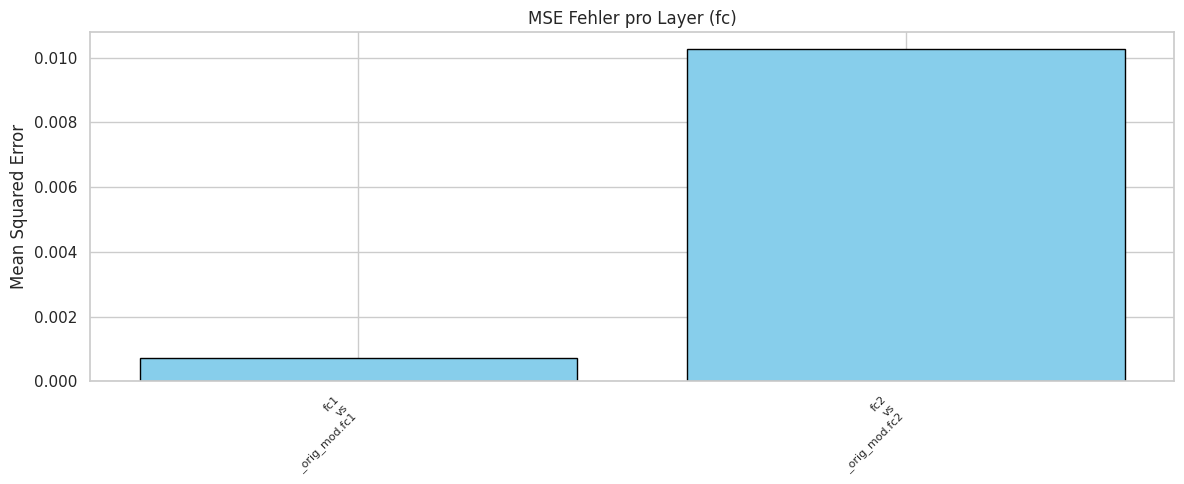

--- Layer-Vergleich (Filter: 'conv') ---
Layer 0: conv1 vs _orig_mod.conv1 -> MSE: 0.000000
Layer 1: conv2 vs _orig_mod.conv2 -> MSE: 0.000000
Layer 2: conv3 vs _orig_mod.conv3 -> MSE: 0.000000
Layer 3: conv4 vs _orig_mod.conv4 -> MSE: 0.000000


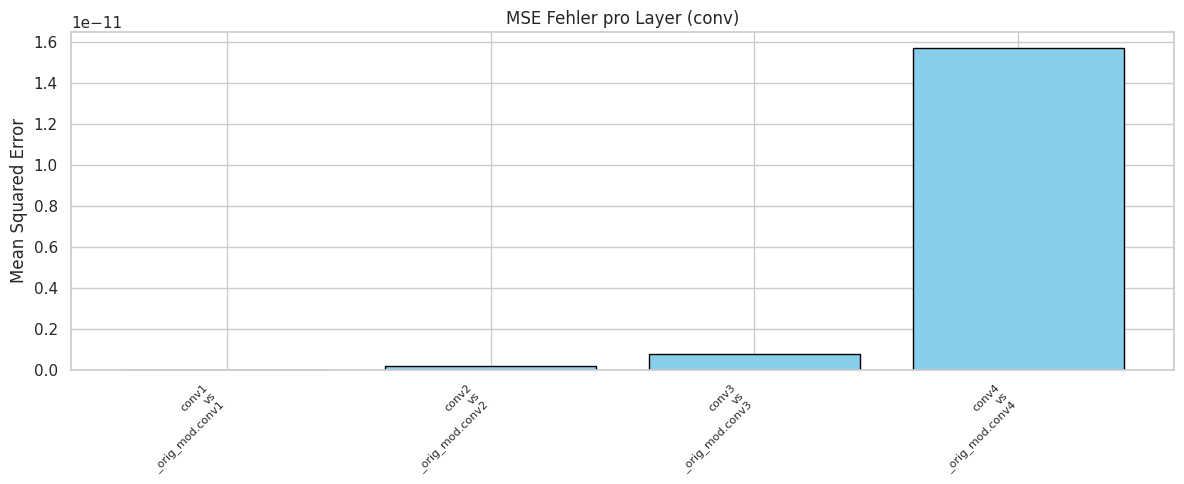

--- Gewichts-Analyse: Base ---
conv1: Min=-0.6030, Max=0.4627, Mean=-0.0027
conv2: Min=-0.6317, Max=0.6718, Mean=-0.0163
conv3: Min=-0.6620, Max=1.3050, Mean=-0.0100
conv4: Min=-0.6174, Max=0.5629, Mean=-0.0083
fc1: Min=-0.8626, Max=0.4163, Mean=-0.0078
fc2: Min=-0.6788, Max=0.5245, Mean=-0.0229


/tmp/ipykernel_178464/1006248076.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weights_data, labels=layer_names, showfliers=False) # Outlier ausblenden für Lesbarkeit


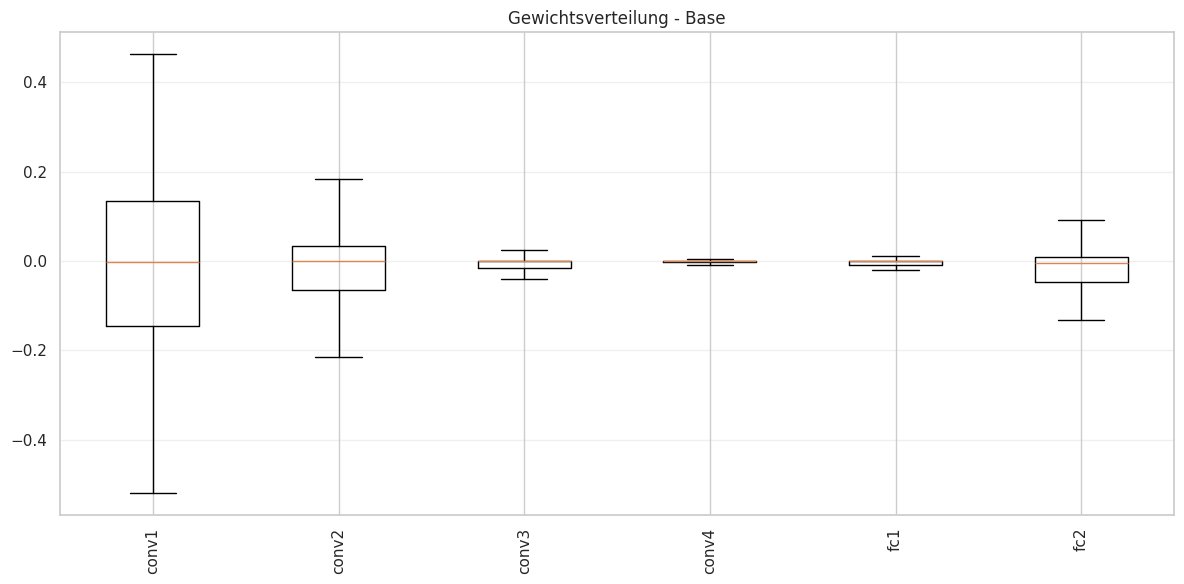

--- Gewichts-Analyse: Quantized Affine Custome ---
conv1: Min=0.0000, Max=255.0000, Mean=144.2442
conv2: Min=0.0000, Max=255.0000, Mean=121.9223
conv3: Min=0.0000, Max=255.0000, Mean=83.7241
conv4: Min=0.0000, Max=255.0000, Mean=130.0915
fc1: Min=0.0000, Max=255.0000, Mean=168.4854
fc2: Min=0.0000, Max=255.0000, Mean=134.2665


/tmp/ipykernel_178464/1006248076.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weights_data, labels=layer_names, showfliers=False) # Outlier ausblenden für Lesbarkeit


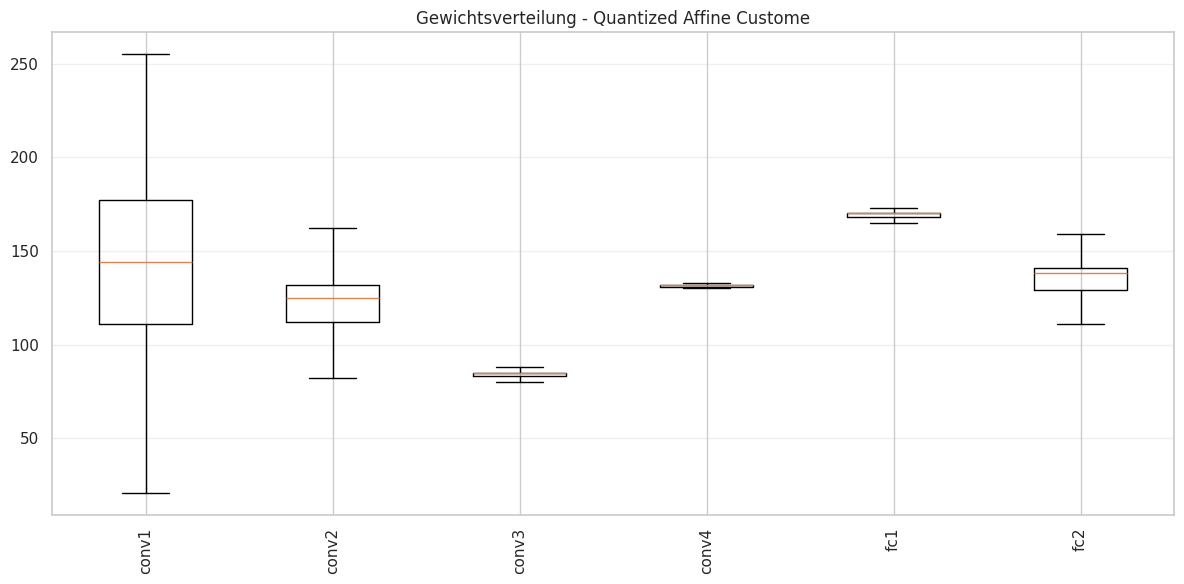

Profiling auf: cuda
Fehler beim Profiling: _apply(): Couldn't swap QuantizedLinear.weight
Tipp: Wenn dies fehlschlägt, versuche das Profiling nur auf 'cpu' laufen zu lassen.


In [ ]:
import torch
import gc

# 1. Daten vorbereiten (Batch Size 1 reicht)
sample_input = next(iter(test_loader))[0].to(DEVICE)

# --- Analyse 1: Activation MSE (Baseline vs. TorchAO) ---
# Schau dir Linear Layer an, da hier oft die Fehler passieren
compare_layer_activations(baseline_model, ao_int8, sample_input, layer_key_substring="fc") 
# Oder für Conv Layer (Name anpassen je nach Summary, z.B. "Conv")
compare_layer_activations(baseline_model, ao_int8, sample_input, layer_key_substring="conv")

# --- Analyse 2: Gewichte prüfen ---
# Hilft zu sehen, ob Quantisierungsskalen (Min/Max) explodieren
analyze_weight_ranges(baseline_model, "Base")
analyze_weight_ranges(fx_model, "FX-Graph")
analyze_weight_ranges(quantized_model_affine, "Quantized Affine Custome")
# Hinweis: Bei FX/AO kann es sein, dass Gewichte "gepackt" sind und hier nicht erscheinen.
# Dann siehst du leere Plots -> Das ist auch eine Info (Struktur hat sich geändert).

# --- Analyse 3: Profiling ---
# Hier siehst du, ob Quant/Dequant Operationen Zeit fressen
# 1. Speicher aufräumen (Linux OOM Killer vermeiden)
gc.collect()
torch.cuda.empty_cache()

# 2. Device wählen (CUDA wenn möglich)
target_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Profiling auf: {target_device}")

# 3. Daten und Modell auf das gleiche Device zwingen
# WICHTIG: Bei kompilierten Modellen kann .to() manchmal tricky sein. 
# Wir verschieben das Modell und den Input explizit.
try:
    # Input verschieben
    input_for_profiling = sample_input.to(target_device)
    
    # Modelle verschieben (falls sie nicht schon da sind)
    # Hinweis: Falls ao_int8 ein kompiliertes Modell ist, löst .to() evtl. eine Neukompilierung aus
    ao_int8 = ao_int8.to(target_device) 
    
    # 4. Profiling starten (angepasster Aufruf)
    print("\n--- Profile TorchAO (Int8) ---")
    # Wir rufen profile_inference mit dem korrekten Device auf
    # (Stelle sicher, dass deine profile_inference Funktion KEIN model.to() intern macht,
    # oder dass sie prüft, wo das Modell ist, wie in meiner korrigierten Version vorher)
    
    # Hier der direkte Aufruf des Profilers, um sicher zu gehen:
    from torch.profiler import profile, record_function, ProfilerActivity
    
    activities = [ProfilerActivity.CPU]
    if target_device == 'cuda':
        activities.append(ProfilerActivity.CUDA)

    with profile(activities=activities, record_shapes=True) as prof:
        with record_function("model_inference"):
            # Warmup
            for _ in range(3): ao_int8(input_for_profiling)
            # Messung
            for _ in range(5): ao_int8(input_for_profiling)
            
    print(prof.key_averages().table(sort_by="cuda_time_total" if target_device == 'cuda' else "cpu_time_total", row_limit=15))

except Exception as e:
    print(f"Fehler beim Profiling: {e}")
    print("Tipp: Wenn dies fehlschlägt, versuche das Profiling nur auf 'cpu' laufen zu lassen.")

In [37]:
import torch
import gc
import copy
from torch.profiler import profile, record_function, ProfilerActivity

# 1. Speicher aufräumen
# if 'ao_int8' in globals(): del ao_int8
# gc.collect()
# torch.cuda.empty_cache()

print("--- Profiling: Neustart auf CPU ---")

# 2. Baseline frisch kopieren und auf CPU zwingen
# Wir nutzen CPU, da deine Quantisierungs-Ops offenbar keine GPU-Unterstützung haben
# model_for_profile = copy.deepcopy(baseline_model).cpu()
input_for_profile = sample_input.cpu()

# # 3. Quantisierung direkt auf der CPU anwenden
# # (Verwende hier dieselbe Methode wie in deinem Experiment oben, z.B. "dynamic" oder "weight_only")
# print("Wende Quantisierung an...")
# ao_int8_profile = Quantization.apply_torchao_quantization(model_for_profile, method="dynamic")

# 4. Profiling starten (Ohne .to() Aufrufe!)
print("Starte Profiler...")
with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    with record_function("model_inference"):
        # Warmup
        for _ in range(3): quantized_model_affine(input_for_profile)
        
        # Messung (10 Durchläufe)
        for _ in range(10): quantized_model_affine(input_for_profile)

# Ergebnis anzeigen
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))

--- Profiling: Neustart auf CPU ---
Starte Profiler...


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [34]:
analyze_weight_ranges(fx_model, "FX-Graph")

--- Gewichts-Analyse: FX-Graph ---
Keine zugreifbaren Gewichte gefunden.
